# L2 · XOR has two different scopes

The lecture's two-ReLU construction solves the **four Boolean truth-table
points** exactly. A Playground-style XOR instead fills four regions of a
square. Extending the same two-ReLU rule to that square reveals a diagonal
band, so we then construct four ReLUs that classify the filled regions.

**Evidence label — constructed + computed:** no optimizer is run here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def relu(t):
    return np.maximum(t, 0.0)

# The four Boolean XOR inputs used in the lecture.
X_bool = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_bool = np.array([0, 1, 1, 0])

## 1. One affine score cannot separate the alternating corners

The zero contour of $w^Tx+b$ is one straight line. Around the square, the
XOR labels alternate $0,1,0,1$, so no single line separates both pairs.

In [2]:
print("x1 x2 | XOR target")
print(np.column_stack([X_bool, y_bool]).astype(int))

x1 x2 | XOR target
[[0 0 0]
 [0 1 1]
 [1 0 1]
 [1 1 0]]


## 2. The deck's two ReLUs solve the four-point truth table

**Evidence label — constructed + computed:** the weights below are chosen
analytically, then the four logits and predictions are computed.

In [3]:
def two_relu_logit(X):
    s = X[:, 0] + X[:, 1]
    hidden = np.column_stack([relu(s), relu(s - 1)])
    z = 2 * hidden[:, 0] - 4 * hidden[:, 1] - 1
    return hidden, z

hidden_bool, z_bool = two_relu_logit(X_bool)
pred_bool = (z_bool >= 0).astype(int)
truth_table_agreement = np.mean(pred_bool == y_bool)

print("x1 x2 | h1 h2 | logit | prediction | target")
print(np.column_stack([X_bool, hidden_bool, z_bool, pred_bool, y_bool]))
print(f"truth-table agreement: {truth_table_agreement:.2f} (4/4)")
assert truth_table_agreement == 1.0

x1 x2 | h1 h2 | logit | prediction | target
[[ 0.  0.  0.  0. -1.  0.  0.]
 [ 0.  1.  1.  0.  1.  1.  1.]
 [ 1.  0.  1.  0.  1.  1.  1.]
 [ 1.  1.  2.  1. -1.  0.  0.]]
truth-table agreement: 1.00 (4/4)


## 3. The same two ReLUs become a diagonal band on filled XOR

Now label every point in $[0,1]^2$ by whether it lies in opposite
half-squares: $(x_1>0.5)\;\mathrm{XOR}\;(x_2>0.5)$. The existing logit
depends only on $x_1+x_2$, so its positive region is the diagonal band
$0.5 \le x_1+x_2 \le 1.5$. Its exact area agreement with filled XOR is
$75\%$; the dense equal-area grid below computes the same value.

In [4]:
n = 400
# One point inside each equal-area cell; the 1/3 offset avoids exact boundaries.
dense_axis = (np.arange(n) + 1/3) / n
dense_x1, dense_x2 = np.meshgrid(dense_axis, dense_axis)
X_dense = np.column_stack([dense_x1.ravel(), dense_x2.ravel()])
y_dense = np.logical_xor(X_dense[:, 0] > 0.5, X_dense[:, 1] > 0.5).astype(int)

_, z_two_dense = two_relu_logit(X_dense)
pred_two_dense = (z_two_dense >= 0).astype(int)
two_relu_filled_agreement = np.mean(pred_two_dense == y_dense)

print(f"two-ReLU agreement on filled-square XOR: {two_relu_filled_agreement:.3f}")
assert two_relu_filled_agreement == 0.75

two-ReLU agreement on filled-square XOR: 0.750


## 4. Four constructed ReLUs classify all four regions

Center the inputs with $u=x_1-0.5$ and $v=x_2-0.5$. The logit

$$z=\operatorname{ReLU}(u-v)+\operatorname{ReLU}(v-u)
-\operatorname{ReLU}(u+v)-\operatorname{ReLU}(-u-v)$$

equals $|u-v|-|u+v|$: it is positive exactly when $u$ and $v$ have
opposite signs. Points on either axis are the class boundary and are excluded
from the verification. These are constructed weights, not learned weights.

In [5]:
def four_relu_logit(X):
    u = X[:, 0] - 0.5
    v = X[:, 1] - 0.5
    hidden = np.column_stack([relu(u - v), relu(v - u),
                              relu(u + v), relu(-u - v)])
    z = hidden @ np.array([1., 1., -1., -1.])
    return hidden, z

# This grid includes both axes so that the boundary exclusion is explicit.
check_axis = np.linspace(0, 1, 401)
check_x1, check_x2 = np.meshgrid(check_axis, check_axis)
X_check = np.column_stack([check_x1.ravel(), check_x2.ravel()])
y_check = np.logical_xor(X_check[:, 0] > 0.5, X_check[:, 1] > 0.5).astype(int)
off_axes = ~np.isclose(X_check[:, 0], 0.5) & ~np.isclose(X_check[:, 1], 0.5)

_, z_four_check = four_relu_logit(X_check)
pred_four_check = (z_four_check > 0).astype(int)
four_relu_regional_agreement = np.mean(pred_four_check[off_axes] == y_check[off_axes])

print(f"four-ReLU agreement off the axes: {four_relu_regional_agreement:.3f}")
print(f"verified non-boundary points: {off_axes.sum():,}")
assert four_relu_regional_agreement == 1.0

four-ReLU agreement off the axes: 1.000
verified non-boundary points: 160,000


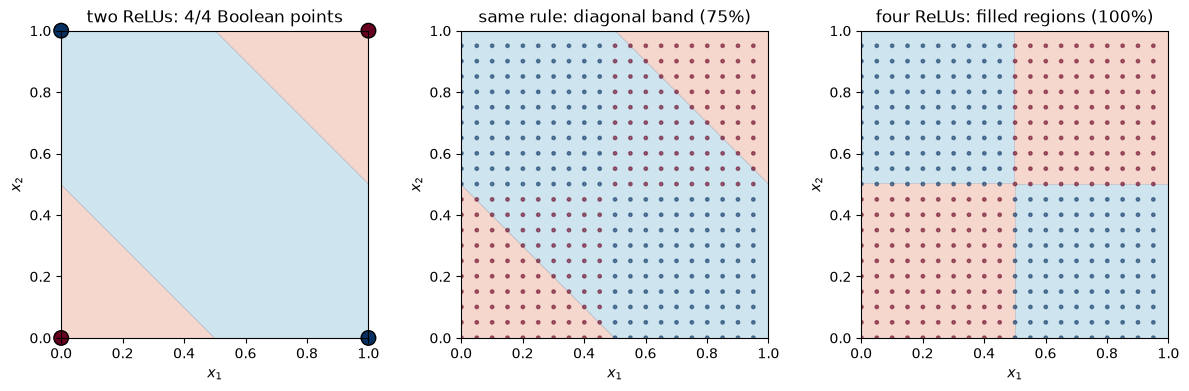

In [6]:
# Constructed decision regions: background = prediction, points = target.
plot_axis = np.linspace(0, 1, 301)
plot_x1, plot_x2 = np.meshgrid(plot_axis, plot_axis)
X_plot = np.column_stack([plot_x1.ravel(), plot_x2.ravel()])
_, z_two_plot = two_relu_logit(X_plot)
_, z_four_plot = four_relu_logit(X_plot)
regions = [(z_two_plot >= 0).reshape(plot_x1.shape),
           (z_two_plot >= 0).reshape(plot_x1.shape),
           (z_four_plot > 0).reshape(plot_x1.shape)]
titles = ["two ReLUs: 4/4 Boolean points",
          "same rule: diagonal band (75%)",
          "four ReLUs: filled regions (100%)"]

sample_points = X_dense.reshape(n, n, 2)[::20, ::20].reshape(-1, 2)
sample_targets = y_dense.reshape(n, n)[::20, ::20].ravel()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for i, (ax, region, title) in enumerate(zip(axes, regions, titles)):
    ax.contourf(plot_x1, plot_x2, region, levels=[-0.5, 0.5, 1.5],
                cmap="RdBu", alpha=0.32)
    if i == 0:
        ax.scatter(X_bool[:, 0], X_bool[:, 1], c=y_bool, cmap="RdBu",
                   vmin=0, vmax=1, edgecolors="black", s=110, clip_on=False)
    else:
        ax.scatter(sample_points[:, 0], sample_points[:, 1], c=sample_targets,
                   cmap="RdBu", vmin=0, vmax=1, s=6, alpha=0.55)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=title,
           xlim=(0, 1), ylim=(0, 1), aspect="equal")
plt.show()

## Takeaway

- **Four Boolean points:** the lecture's two constructed ReLUs give exact 4/4 agreement.
- **Filled-square XOR:** the same logit depends only on $x_1+x_2$, draws a diagonal
  band, and agrees over $75\%$ of the square.
- **Filled regions:** four constructed ReLUs implement $|u-v|-|u+v|$ and classify
  every non-boundary grid point correctly.
- These checks establish representational scope only; they make no claim about
  optimization, convergence, or generalization.

Try the same dataset switch in the [ReLU Playground](https://nipunbatra.github.io/interactive-articles/mlp-decision-boundary/).